### Installing dependencies from the requirements file

In [53]:
!pip install -r requirements.txt

  Using cached attrs-25.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached certifi-2025.4.26-py3-none-any.whl.metadata (2.5 kB)
  Using cached charset_normalizer-3.4.2-cp312-cp312-win_amd64.whl.metadata (36 kB)
  Using cached contourpy-1.3.2-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached decorator-5.2.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached fonttools-4.57.0-cp312-cp312-win_amd64.whl.metadata (104 kB)
  Using cached fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached huggingface_hub-0.30.2-py3-none-any.whl.metadata (13 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached ipython-9.2.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached ipython_pygments_lexers-1.1.1-py3-none-any.whl.metadata (1.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached joblib-1.5.0-py3-no

ERROR: Ignored the following versions that require a different python version: 0.55.2 Requires-Python <3.5; 1.10.0 Requires-Python >=3.8,<3.12; 1.10.0rc1 Requires-Python >=3.8,<3.12; 1.10.0rc2 Requires-Python >=3.8,<3.12; 1.10.1 Requires-Python >=3.8,<3.12; 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-P

## Importing the required libraries

In [4]:
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

# Keras-Tuner
import keras_tuner as kt

# Hugging Face
from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
import torch

# LIME for explainability
from lime.lime_text import LimeTextExplainer

### Setting a seed

In [5]:
#Setting a seed so that my results stay consistent each time I run the code
import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): 
    torch.cuda.manual_seed_all(SEED)

## Data loading and preprocessing 

In [6]:
data = pd.read_csv(

    'Dataset.csv',
    encoding='latin-1',
    names=['target','id','date','flag','user','text']

)

In [7]:
#printing first few rows 
data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


 ### Maping labels 0 as negative and 1 as positive

In [8]:
data['sentiment'] = data['target'].map({0: 0, 4: 1}) 

### Cleaning the text which removes URLS, mentions, hashtags , keep letters spaces and collapse spaces

In [9]:
def clean_text(s):
    s = str(s).lower()                          # converting into lowercase
    s = re.sub(r'http\S+|www\.\S+', '', s)      # this removes URLs
    s = re.sub(r'@\w+', '', s)                  # this removes mentions
    s = re.sub(r'#\w+', '', s)                  # this removes hashtags
    s = re.sub(r'[^a-z\s]', '', s)              # keep letters & spaces
    s = re.sub(r'\s+', ' ', s).strip()          # collapse spaces
    return s

In [10]:
data['clean_text'] = data['text'].apply(clean_text)

In [11]:
data.clean_text

0          awww thats a bummer you shoulda got david carr...
1          is upset that he cant update his facebook by t...
2          i dived many times for the ball managed to sav...
3             my whole body feels itchy and like its on fire
4          no its not behaving at all im mad why am i her...
                                 ...                        
1599995    just woke up having no school is the best feel...
1599996      thewdbcom very cool to hear old walt interviews
1599997    are you ready for your mojo makeover ask me fo...
1599998    happy th birthday to my boo of alll time tupac...
1599999                                                happy
Name: clean_text, Length: 1600000, dtype: object

### Checking Missing & duplicates Values

In [12]:
print("Nulls:\n", data.isnull().sum())
print("Duplicate texts:", data.duplicated(subset=['clean_text']).sum())
data = data.drop_duplicates(subset=['clean_text'])

Nulls:
 target        0
id            0
date          0
flag          0
user          0
text          0
sentiment     0
clean_text    0
dtype: int64
Duplicate texts: 82567


## Explodatory Data Analysis

### Class balance

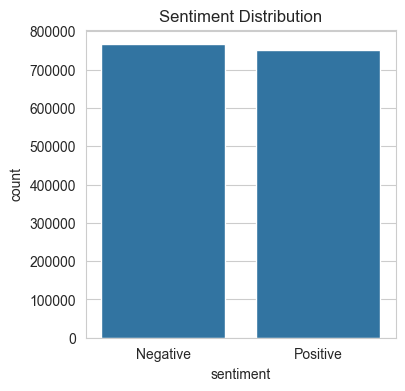

In [13]:
sns.set_style('whitegrid')

plt.figure(figsize=(4,4))
sns.countplot(x='sentiment', data=data)
plt.xticks([0,1], ['Negative','Positive'])
plt.title('Sentiment Distribution')
plt.show()

### Tweet length distribution

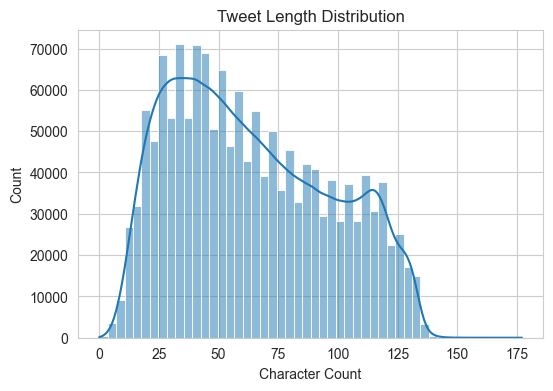

In [14]:
data['length'] = data['clean_text'].str.len()
plt.figure(figsize=(6,4))
sns.histplot(data['length'], bins=50, kde=True)
plt.title('Tweet Length Distribution')
plt.xlabel('Character Count')
plt.show()

### Top unigrams & bigrams

In [15]:
vect = CountVectorizer(ngram_range=(1,2),
                       max_features=20,
                       stop_words='english')
X_ng = vect.fit_transform(data['clean_text'])
freq = pd.DataFrame({
    'ngram': vect.get_feature_names_out(),
    'count': X_ng.sum(axis=0).A1
}).sort_values('count', ascending=False)
print("Top 10 n-grams:\n", freq.head(10))

Top 10 n-grams:
     ngram   count
6      im  175657
7    just  123403
4    good   83921
1     day   81175
9    like   76574
2    dont   65885
17  today   63576
3   going   62978
11   love   61688
19   work   60142


### Text length analysis

<Axes: title={'center': 'word_count'}, xlabel='target'>

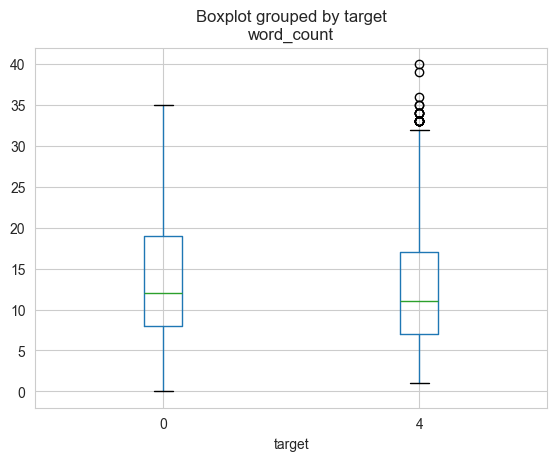

In [16]:
data['char_count'] = data['clean_text'].str.len()
data['word_count'] = data['clean_text'].str.split().apply(len)
data.boxplot(column='word_count', by='target')

### Word frequencies

In [17]:
from collections import Counter
all_words = Counter(" ".join(data['clean_text']).lower().split())
print(all_words.most_common(20))

[('i', 735588), ('to', 555559), ('the', 511410), ('a', 371283), ('my', 309073), ('and', 296048), ('you', 256851), ('is', 231754), ('it', 227505), ('in', 212098), ('for', 211230), ('of', 181625), ('im', 175657), ('on', 163477), ('me', 155600), ('so', 147283), ('have', 142335), ('that', 138329), ('but', 126479), ('just', 123403)]


In [18]:
# droping the PDT token
data['date_clean'] = data['date'].str.replace(r' [A-Z]{3,4} ', ' ', regex=True)

# parsing by format
data['date_parsed'] = pd.to_datetime(
    data['date_clean'],
    format='%a %b %d %H:%M:%S %Y',  # e.g. Mon Apr 06 22:19:49 2009
    errors='coerce'
)


### DATE-DERIVED FEATURES

In [19]:
# extracting granular features
data['year']    = data['date_parsed'].dt.year
data['month']   = data['date_parsed'].dt.month
data['day']     = data['date_parsed'].dt.day
data['weekday'] = data['date_parsed'].dt.day_name()
data['hour']    = data['date_parsed'].dt.hour

### Plotting tweets by hour

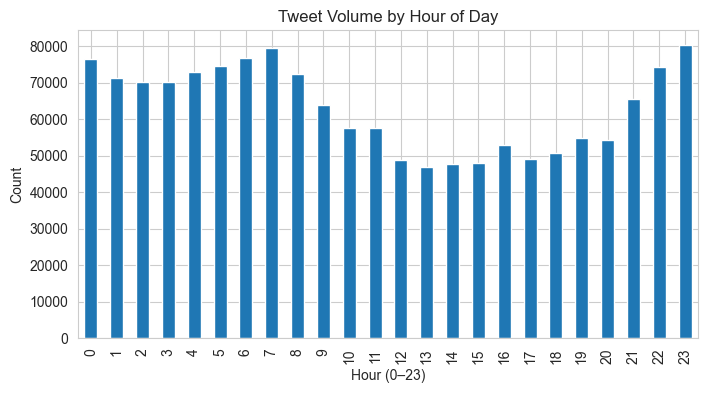

In [20]:
plt.figure(figsize=(8,4))
data['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Tweet Volume by Hour of Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Count")
plt.show()

### Plotting tweets by weekday

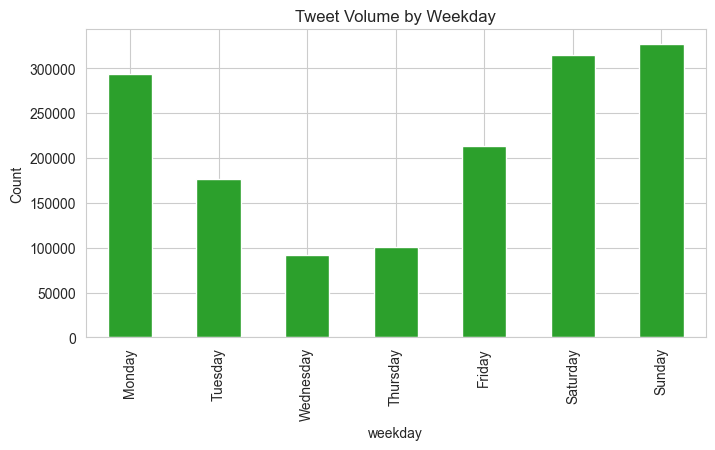

In [21]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(8,4))
data['weekday'].value_counts().reindex(weekday_order).plot(kind='bar', color='C2')
plt.title("Tweet Volume by Weekday")
plt.ylabel("Count")
plt.show()

### USER-LEVEL AGGREGATES

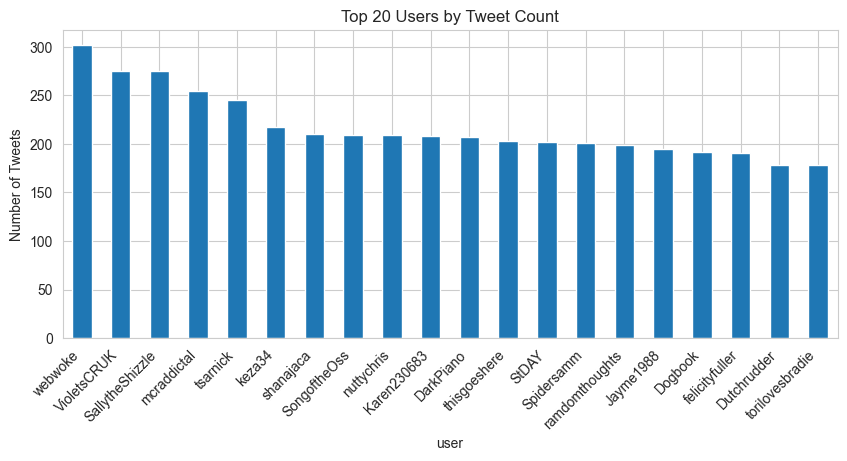

In [22]:
# a)Finding Top 20 users by tweet count
top_users = data['user'].value_counts().head(20)
plt.figure(figsize=(10,4))
top_users.plot(kind='bar')
plt.title("Top 20 Users by Tweet Count")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha='right')
plt.show()

### % of "power users" with >100 tweets

In [23]:
user_counts = data['user'].value_counts()
pct_power = (user_counts > 100).sum() / user_counts.shape[0] * 100
print(f"{pct_power:.2f}% of users authored more than 100 tweets.")

0.02% of users authored more than 100 tweets.


### LEXICAL ANALYSIS

In [24]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [25]:
# downloading stopwords 
nltk.download('stopwords')
stop = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\phani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
# tokenizing and removing stopwords
data['tokens'] = (data['clean_text']
                .str.lower()
                .str.findall(r'\b\w+\b')
                .apply(lambda toks: [t for t in toks if t not in stop]))

# overall top 20 words
all_words = Counter(w for toks in data['tokens'] for w in toks)
print("Overall Top 20 Words:", all_words.most_common(20))

Overall Top 20 Words: [('im', 175657), ('good', 83921), ('day', 81175), ('get', 79324), ('like', 76574), ('go', 71544), ('dont', 65885), ('today', 63576), ('going', 62978), ('love', 61688), ('cant', 61548), ('work', 60142), ('got', 59935), ('time', 55309), ('back', 54541), ('lol', 54460), ('u', 52335), ('one', 51549), ('know', 49772), ('really', 48640)]


### top 10 words per sentiment

In [27]:
for sentiment in sorted(data['target'].unique()):
    cw = Counter(w for toks in data.loc[data['target']==sentiment,'tokens'] for w in toks)
    print(f"Sentiment={sentiment} Top 10:", cw.most_common(10))

Sentiment=0 Top 10: [('im', 101402), ('get', 45057), ('go', 44187), ('dont', 44045), ('cant', 42853), ('work', 41821), ('like', 40277), ('day', 38858), ('today', 35734), ('going', 32973)]
Sentiment=4 Top 10: [('im', 74255), ('good', 56559), ('love', 45343), ('day', 42317), ('like', 36297), ('get', 34267), ('lol', 32915), ('going', 30005), ('u', 29832), ('time', 28764)]


### top 20 bigrams & trigrams (regardless of class)

In [28]:
ngram_vect = CountVectorizer(ngram_range=(2,3),
                             stop_words='english',
                             max_features=20)
ngram_vect.fit(data['clean_text'].fillna(''))
print("Top 20 n-grams:", ngram_vect.get_feature_names_out())

Top 20 n-grams: ['dont know' 'dont like' 'dont think' 'dont want' 'feel like'
 'getting ready' 'going bed' 'good day' 'good luck' 'good morning'
 'good night' 'im going' 'im gonna' 'im sorry' 'im sure' 'just got'
 'let know' 'looking forward' 'looks like' 'think im']


### ADVANCED EXPLORATIONS: LDA TOPIC MODELING

In [29]:
from sklearn.decomposition import LatentDirichletAllocation

# vectorizing text to document-term matrix
vect = CountVectorizer(max_df=0.95,
                       min_df=50,
                       stop_words='english')
dtm = vect.fit_transform(data['clean_text'].fillna(''))

# fitting LDA
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics,
                                random_state=42,
                                learning_method='batch')
lda.fit(dtm)

# showing top terms per topic
terms = vect.get_feature_names_out()
for idx, comp in enumerate(lda.components_):
    top_terms = [terms[i] for i in comp.argsort()[-10:][::-1]]
    print(f"Topic {idx}: {', '.join(top_terms)}")


Topic 0: work, new, thanks, good, ill, getting, amp, im, looking, just
Topic 1: dont, like, im, know, really, want, feel, bad, think, need
Topic 2: just, sad, watching, oh, love, did, lol, want, miss, saw
Topic 3: im, going, just, bed, twitter, home, got, time, yeah, work
Topic 4: day, im, good, today, hope, love, going, night, tomorrow, great


### CORRELATION MATRIX 

                target  char_count  word_count  avg_word_len
target        1.000000   -0.051705   -0.073530      0.082854
char_count   -0.051705    1.000000    0.970215      0.043036
word_count   -0.073530    0.970215    1.000000     -0.141070
avg_word_len  0.082854    0.043036   -0.141070      1.000000


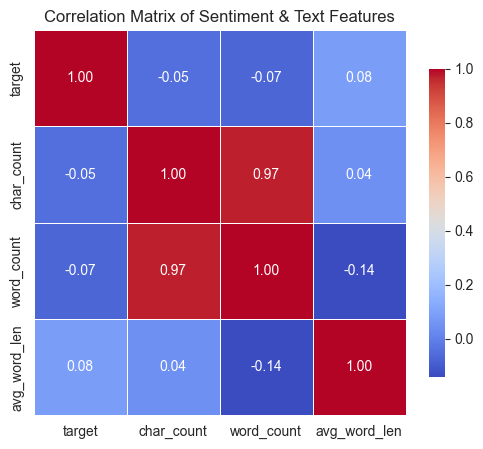

In [30]:
import seaborn as sns

#Here we are Creating some simple numeric features
data['char_count']    = data['clean_text'].str.len()                                 # total characters
data['word_count']    = data['clean_text'].str.split().str.len()                     # total words
data['avg_word_len']  = data['char_count'] / data['word_count'].replace(0,1)     # average word length

#Selecting the numeric columns for correlation
num_cols = ['target', 'char_count', 'word_count', 'avg_word_len']
corr_df  = data[num_cols].corr()

# Displaying the raw correlation matrix
print(corr_df)

# Ploting a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    cbar_kws={"shrink":0.8}
)
plt.title("Correlation Matrix of Sentiment & Text Features")
plt.show()


### BUILD ANALYTICS BASE TABLE 

In [31]:
abt = data.copy()

# length of each tweet
abt['text_length'] = abt['clean_text'].str.len()

# number of words per tweet
abt['num_words'] = abt['clean_text'].str.split().str.len()

# count of hashtags (#word) and mentions (@user)
abt['num_hashtags'] = abt['clean_text'].str.count(r'#\w+')
abt['num_mentions'] = abt['clean_text'].str.count(r'@\w+')

# flag for presence of a URL
abt['has_url'] = abt['clean_text'].str.contains(r'https?://', regex=True).astype(int)

# unique-word ratio (vocabulary richness)
abt['unique_word_ratio'] = (
    abt['clean_text']
       .str.lower()
       .str.split()
       .apply(lambda w: len(set(w)) / len(w) if w else 0)
)

# mapping target to a label
abt['sentiment_label'] = abt['target'].map({0:'negative', 4:'positive'})

# Date/time features
abt['hour']       = abt['date_parsed'].dt.hour
abt['day_of_week']= abt['date_parsed'].dt.dayofweek      # Monday=0…Sunday=6
abt['month']      = abt['date_parsed'].dt.month

# Quick check 
print("ABT shape:", abt.shape)
display(abt.head())


ABT shape: (1517433, 28)


,target,id,date,flag,user,text,sentiment,clean_text,length,char_count,...,tokens,avg_word_len,text_length,num_words,num_hashtags,num_mentions,has_url,unique_word_ratio,sentiment_label,day_of_week
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,awww thats a bummer you shoulda got david carr...,70,70,...,"[awww, thats, bummer, shoulda, got, david, car...",4.375000,70,16,0,0,0,1.0000,negative,0
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,0,is upset that he cant update his facebook by t...,104,104,...,"[upset, cant, update, facebook, texting, might...",4.952381,104,21,0,0,0,1.0000,negative,0
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,0,i dived many times for the ball managed to sav...,73,73,...,"[dived, many, times, ball, managed, save, rest...",4.562500,73,16,0,0,0,0.9375,negative,0
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,0,my whole body feels itchy and like its on fire,46,46,...,"[whole, body, feels, itchy, like, fire]",4.600000,46,10,0,0,0,1.0000,negative,0
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",0,no its not behaving at all im mad why am i her...,85,85,...,"[behaving, im, mad, cant, see]",4.250000,85,20,0,0,0,0.9000,negative,0


### Word Clouds

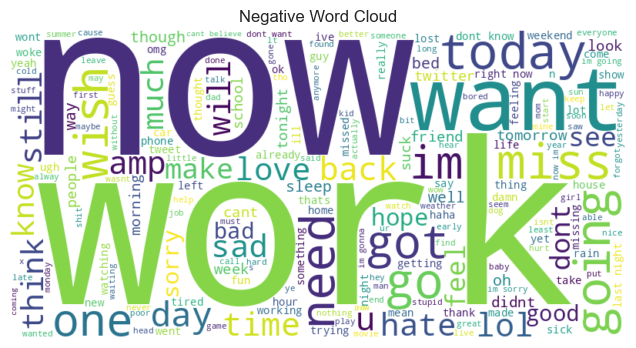

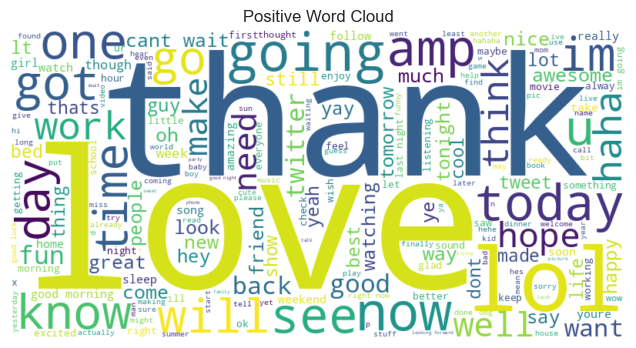

In [32]:
for label, title in [(0,'Negative'), (1,'Positive')]:
    text = " ".join(data.loc[data['sentiment']==label, 'clean_text'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off'); plt.title(f'{title} Word Cloud')
    plt.show()

### Daily twitter volume

C:\Users\phani\AppData\Local\Programs\Python\Python312\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname PDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


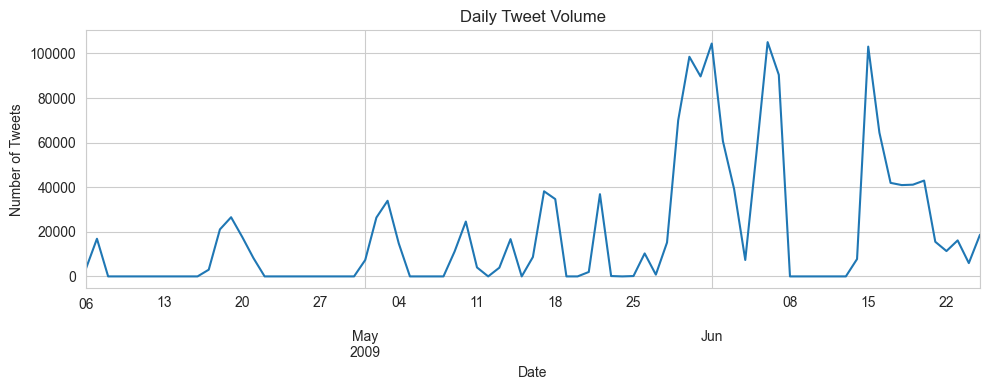

In [33]:
from dateutil import parser

# 1. Parsing using dateutil (handles “PDT”, “GMT”, etc., out of the box)
data['date_parsed'] = data['date'].apply(parser.parse)

# 2. Dropping rows if still failed 
data = data.dropna(subset=['date_parsed'])

# 3. Resampling to daily counts
daily = data.set_index('date_parsed')['sentiment'].resample('D').count()


plt.figure(figsize=(10,4))
daily.plot()
plt.title('Daily Tweet Volume')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

### A 20% sample of the dataset is used, preserving the balance of sentiment labels.

In [34]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

sampled_data = data.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=RANDOM_SEED)
).reset_index(drop=True)

print(f"Original dataset size: {len(data)}")
print(f"Sampled dataset size (20%): {len(sampled_data)}")

print("\nClass distribution in 20% sample:")
print(sampled_data['sentiment'].value_counts(normalize=True))

C:\Users\phani\AppData\Local\Temp\ipykernel_6332\3251600914.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = data.groupby('sentiment', group_keys=False).apply(


Original dataset size: 1517433
Sampled dataset size (20%): 303487

Class distribution in 20% sample:
sentiment
0    0.504789
1    0.495211
Name: proportion, dtype: float64


# Logistic Regression baseline

### Spliting the data

In [35]:
X_train, X_val, y_train, y_val = train_test_split(
    sampled_data['clean_text'], sampled_data['sentiment'],
    test_size=0.2, random_state=42, stratify=sampled_data['sentiment']
)

### Baseline pipeline

In [36]:
import time
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf',   LogisticRegression(max_iter=1000))
])

start = time.time()
pipe.fit(X_train, y_train)
lr_train_time = time.time() - start

start = time.time()
lr_preds = pipe.predict(X_val)
lr_pred_time = time.time() - start

print(pipe)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [37]:
import pickle

# Saving Logistic Regression model for deployment
with open("logreg_model.pkl", "wb") as f:
    pickle.dump(pipe.named_steps['clf'], f)

# Saving TF-IDF vectorizer for deployment
with open("logreg_vectorizer.pkl", "wb") as f:
    pickle.dump(pipe.named_steps['tfidf'], f)


### Evaluation for Logistic Regression

In [38]:
preds = pipe.predict(X_val)
print(classification_report(y_val, preds, target_names=['Negative','Positive']))

              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76     30640
    Positive       0.75      0.79      0.77     30058

    accuracy                           0.77     60698
   macro avg       0.77      0.77      0.77     60698
weighted avg       0.77      0.77      0.77     60698



### ROC-AUC for Logistic Regression 

Logistic Regression ROC-AUC Score: 0.8455


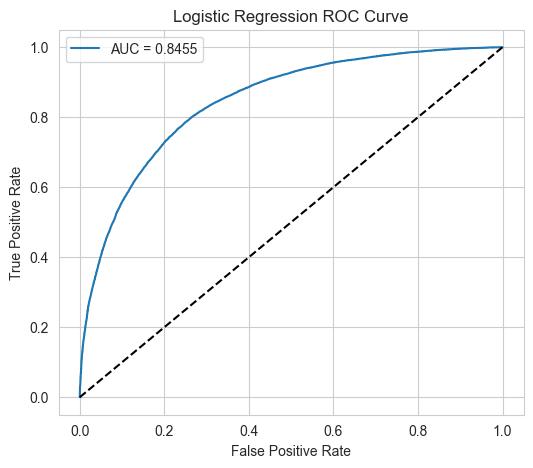

In [39]:
# Probabilities required for ROC curve
lr_probs = pipe.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val, lr_probs)

print(f"Logistic Regression ROC-AUC Score: {lr_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, lr_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {lr_auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()


### Confusion Matrix for Logistic regression

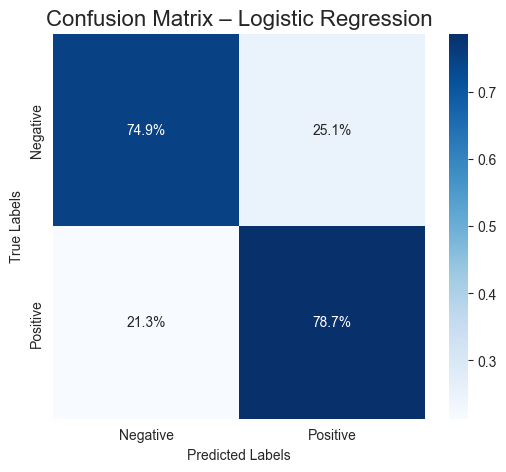

In [40]:
cm = confusion_matrix(y_val, preds, normalize='true')
labels = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='.1%', 
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix – Logistic Regression", fontsize=16)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### Tokenizing & pad 

In [41]:
MAX_WORDS = 30_000
MAX_LEN   = 100

# Support vector machine (SVM)

In [42]:
from sklearn.pipeline          import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm               import LinearSVC
from sklearn.model_selection   import GridSearchCV
from sklearn.metrics           import classification_report

### Pipeline for SVM

In [43]:
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.9)),
    ('svc',   LinearSVC(max_iter=5000))
])

### Hyperparameter tuning

In [44]:
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'svc__C': [0.1, 1, 10]
}

In [46]:
start = time.time()
grid_svm = GridSearchCV(
    svm_pipe, param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train, y_train)
svm_train_time = time.time() - start
grid_svm

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_df=0.9,
                                                        stop_words='english')),
                                       ('svc', LinearSVC(max_iter=5000))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=1)

### Evaluation for SVM

In [48]:
print("Best SVM Params:", grid_svm.best_params_)
print("CV F1 Score:", grid_svm.best_score_)

# Evaluation on validation set (SVM)
start = time.time()
y_svm_pred = grid_svm.predict(X_val)
svm_pred_time = time.time() - start
print("\nSVM Classification Report:\n",
      classification_report(y_val, y_svm_pred, target_names=['Negative','Positive']))

Best SVM Params: {'svc__C': 0.1, 'tfidf__ngram_range': (1, 2)}
CV F1 Score: 0.7654539098158282

SVM Classification Report:
               precision    recall  f1-score   support

    Negative       0.78      0.76      0.77     30640
    Positive       0.76      0.78      0.77     30058

    accuracy                           0.77     60698
   macro avg       0.77      0.77      0.77     60698
weighted avg       0.77      0.77      0.77     60698



### SVM ROC-AUC

SVM ROC-AUC Score: 0.8512


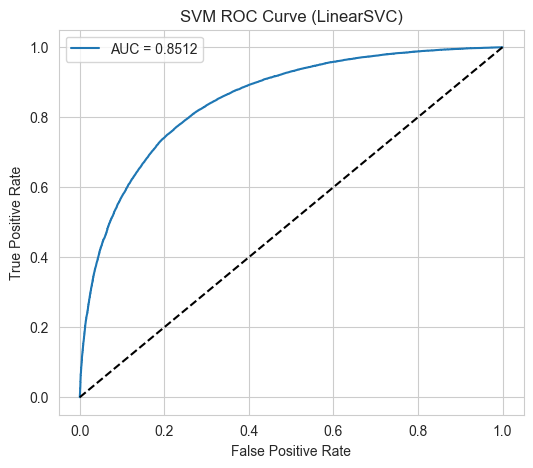

In [49]:
# Best SVM model from grid search
best_svm = grid_svm.best_estimator_

# Decision score to get ROC curve
svm_scores = best_svm.decision_function(X_val)
svm_auc = roc_auc_score(y_val, svm_scores)

print(f"SVM ROC-AUC Score: {svm_auc:.4f}")
# ROC Curve
fpr, tpr, _ = roc_curve(y_val, svm_scores)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {svm_auc:.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve (LinearSVC)")
plt.legend()
plt.show()

### Confusion Matrix – SVM

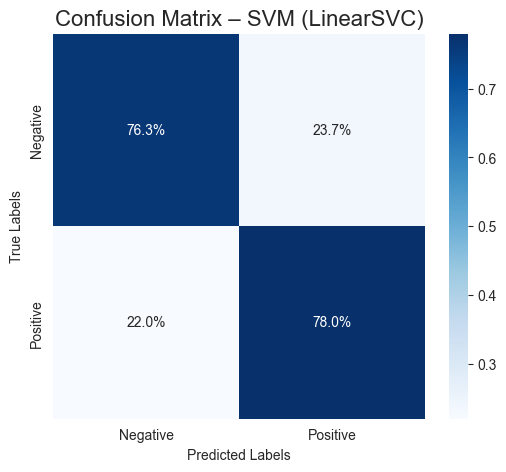

In [50]:
cm_svm = confusion_matrix(y_val, y_svm_pred, normalize='true')
labels = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, cmap='Blues', fmt='.1%', 
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix – SVM (LinearSVC)", fontsize=16)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### Saving SVM model

In [51]:
import pickle

# Saving the best SVM model from grid search for deployment
with open("svm_model.pkl", "wb") as f:
    pickle.dump(grid_svm.best_estimator_, f)

# Saving the TF-IDF vectorizer for deployment
with open("svm_vectorizer.pkl", "wb") as f:
    pickle.dump(grid_svm.best_estimator_.named_steps['tfidf'], f)


In [54]:
import torch
from torch.utils.data import TensorDataset

In [55]:
!pip install datasets


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# BERT MODEL

In [56]:
from datasets import Dataset

In [58]:
#  Preparing HF Dataset
# We are using a small pandas slice to match our X_val/y_val split
hf_df = pd.DataFrame({'text': X_train, 'label': y_train})
val_df = pd.DataFrame({'text': X_val,   'label': y_val})


In [59]:
# Tokenizing
tokenizer_bert = BertTokenizerFast.from_pretrained('bert-base-uncased')
def tokenize_fn(batch):
    return tokenizer_bert(batch['text'], padding=True, truncation=True, max_length=64)

In [70]:
from datasets import Dataset

# Converting pandas DataFrames to HF Datasets
train_ds = Dataset.from_pandas(hf_df)
val_ds   = Dataset.from_pandas(val_df)

# Tokenizing all rows at once 
train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

# Formatting for PyTorch
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/242789 [00:00<?, ? examples/s]

Map:   0%|          | 0/60698 [00:00<?, ? examples/s]

In [71]:
enc_train = tokenizer_bert(
    X_train.tolist(),
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors='pt'
)

In [72]:
enc_val = tokenizer_bert(
    X_val.tolist(),
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors='pt'
)

In [73]:
# Building TensorDatasets
train_ds = TensorDataset(
    enc_train['input_ids'],
    enc_train['attention_mask'],
    torch.tensor(y_train.values)
)
val_ds = TensorDataset(
    enc_val['input_ids'],
    enc_val['attention_mask'],
    torch.tensor(y_val.values)
)


### DataLoaders

In [74]:
# DataLoaders
import torch
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0,     
    pin_memory=False    
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    num_workers=0,
    pin_memory=False
)


In [75]:
import torch
from torch.optim import AdamW
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup

In [76]:
# Instantiating the model
model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [77]:
# Moving it to the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_bert.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [78]:
#Seting up optimizer and scheduler
optimizer = AdamW(model_bert.parameters(), lr=2e-5)

In [80]:

epochs = 1
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [81]:
# Checking for gpu
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


GPU available: False
Device name: CPU only


In [82]:
from tqdm import tqdm
import torch
start = time.time()

for epoch in range(1, epochs + 1):
    model_bert.train()
    total_train_loss = 0

    # Progreess bar for each batch in the epoch
    loop = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)

    for input_ids, attn_mask, labels in loop:
        # Moving data to GPU if available
        input_ids, attn_mask, labels = [t.to(device) for t in (input_ids, attn_mask, labels)]

        # Forwarding pass
        outputs = model_bert(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss = outputs.loss
        total_train_loss += loss.item()

        # Backwarding pass and optimizating
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Updating progress bar with current loss
        loop.set_postfix(batch_loss=loss.item())

    #Here we are calculating and printing average training loss
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch}/{epochs} — Average Train Loss: {avg_train_loss:.4f}")
bert_train_time = time.time() - start
print(f"Total BERT Training Time: {bert_train_time:.2f} seconds")

Epoch 1/1 — Average Train Loss: 0.3847

Total BERT Training Time: 49295.60 seconds


In [83]:
from tqdm import tqdm
from sklearn.metrics import classification_report
start = time.time()

# Validating with probs
model_bert.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    loop = tqdm(val_loader, desc=f"Validating", leave=False)
    for input_ids, attn_mask, labels in loop:
        input_ids = input_ids.to(device)
        attn_mask = attn_mask.to(device)

        logits = model_bert(input_ids=input_ids, attention_mask=attn_mask).logits
        probs = torch.nn.functional.softmax(logits, dim=1)[:, 1].cpu()  # probs for class 1

        all_probs.append(probs)
        all_labels.append(labels)

bert_pred_time = time.time() - start
print(f"BERT Prediction Time: {bert_pred_time:.4f} seconds")

# Concatenating everything
all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)

# Converting probabilities to predicted class labels (0 or 1)
all_preds = (all_probs > 0.5).int()

# Classification report
print(f"\nEpoch {epoch} — Validation Report:\n")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

BERT Prediction Time: 2456.2153 seconds

Epoch 1 — Validation Report:

              precision    recall  f1-score   support

    Negative       0.84      0.86      0.85     30640
    Positive       0.85      0.83      0.84     30058

    accuracy                           0.84     60698
   macro avg       0.84      0.84      0.84     60698
weighted avg       0.84      0.84      0.84     60698



In [84]:
from transformers import BertTokenizer
# saving the bert model folder for deployment
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_model")


('bert_model\\tokenizer_config.json',
 'bert_model\\special_tokens_map.json',
 'bert_model\\vocab.txt',
 'bert_model\\added_tokens.json')

## ROC CURVE

ROC AUC Score: 0.9238


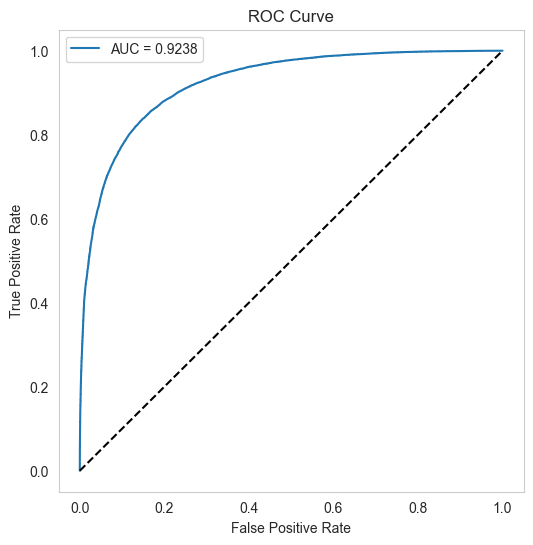

In [85]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# AUC Score
auc = roc_auc_score(all_labels, all_probs)
print(f"ROC AUC Score: {auc:.4f}")

# Plotting ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


## CONFUSION MATRIX

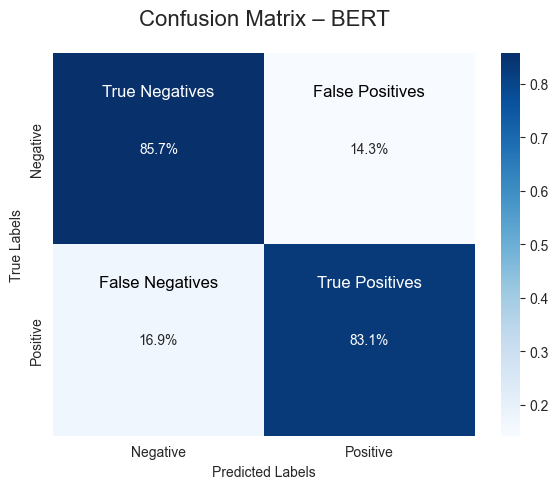

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Computing normalized confusion matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')  # row-normalized (per class)
labels = ['Negative', 'Positive'] 

# Plotting with seaborn
plt.figure(figsize=(6, 5))
ax = sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues', cbar=True,
                 xticklabels=labels, yticklabels=labels,
                 )

# Customing annotations
ax.text(0.5, 0.2, 'True Negatives', color='white', ha='center', va='center', fontsize=12)
ax.text(1.5, 0.2, 'False Positives', color='black', ha='center', va='center', fontsize=12)
ax.text(0.5, 1.2, 'False Negatives', color='black', ha='center', va='center', fontsize=12)
ax.text(1.5, 1.2, 'True Positives', color='white', ha='center', va='center', fontsize=12)

# Titles and labels
plt.title("Confusion Matrix – BERT", fontsize=16, pad=20)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()


### Model Performance Comparison Table

In [87]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Logistic Regression Metrics
lr_acc  = accuracy_score(y_val, preds)
lr_prec = precision_score(y_val, preds)
lr_rec  = recall_score(y_val, preds)
lr_f1   = f1_score(y_val, preds)
lr_auc  = roc_auc_score(y_val, lr_probs)

# SVM Metrics
svm_acc  = accuracy_score(y_val, y_svm_pred)
svm_prec = precision_score(y_val, y_svm_pred)
svm_rec  = recall_score(y_val, y_svm_pred)  
svm_f1   = f1_score(y_val, y_svm_pred)
svm_auc  = roc_auc_score(y_val, svm_scores)

# BERT Metrics
bert_acc  = accuracy_score(all_labels, all_preds)
bert_prec = precision_score(all_labels, all_preds)
bert_rec  = recall_score(all_labels, all_preds)
bert_f1   = f1_score(all_labels, all_preds)
bert_auc  = roc_auc_score(all_labels, all_probs)

# Here we are creating comparison table
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (LinearSVC)', 'BERT'],
    'Accuracy': [lr_acc, svm_acc, bert_acc],
    'Precision': [lr_prec, svm_prec, bert_prec],
    'Recall': [lr_rec, svm_rec, bert_rec],
    'F1 Score': [lr_f1, svm_f1, bert_f1],
    'ROC-AUC': [lr_auc, svm_auc, bert_auc]
})

print("Model Performance Comparison")
display(results_df.round(4))



 Model Performance Comparison 



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7677,0.7545,0.7869,0.7704,0.8455
1,SVM (LinearSVC),0.7715,0.7637,0.7798,0.7717,0.8512
2,BERT,0.8444,0.8512,0.8310,0.8410,0.9238


### Bar Plot: F1 Score Comparison 

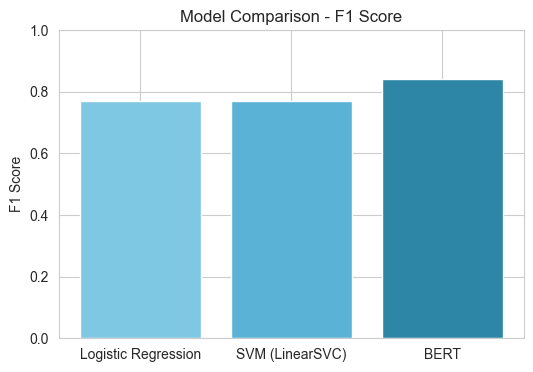

In [101]:
plt.figure(figsize=(6,4))
plt.bar(results_df['Model'], results_df['F1 Score'], color=['#7EC8E3','#5AB2D6','#2E86A6'])
plt.title("Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.show()

### Bar Plot: ROC-AUC Comparison

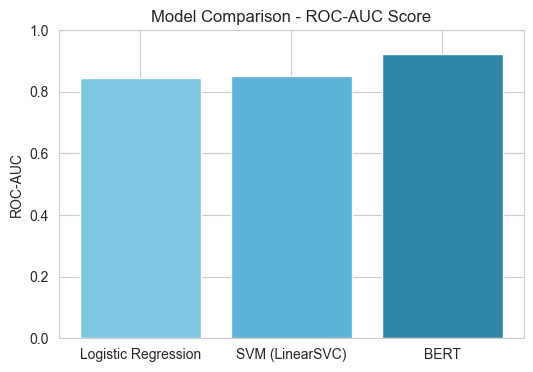

In [102]:
plt.figure(figsize=(6,4))
plt.bar(results_df['Model'], results_df['ROC-AUC'], color=['#7EC8E3','#5AB2D6','#2E86A6'])
plt.title("Model Comparison - ROC-AUC Score")
plt.ylabel("ROC-AUC")
plt.ylim(0,1)
plt.show()    

### FINAL COMPUTATIONAL COST COMPARISON

In [91]:
import pandas as pd

df_timing = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Training Time (s)": round(lr_train_time, 4),
        "Prediction Time (s)": round(lr_pred_time, 4)
    },
    {
        "Model": "Linear SVM",
        "Training Time (s)": round(svm_train_time, 4),
        "Prediction Time (s)": round(svm_pred_time, 4)
    },
    {
        "Model": "BERT (bert-base-uncased)",
        "Training Time (s)": round(bert_train_time, 4),
        "Prediction Time (s)": round(bert_pred_time, 4)
    }
])

print(" FINAL COMPUTATIONAL COST COMPARISON ")
print(df_timing)



 FINAL COMPUTATIONAL COST COMPARISON 

                      Model  Training Time (s)  Prediction Time (s)
0       Logistic Regression             9.1873               1.1889
1                Linear SVM           186.0655               2.4751
2  BERT (bert-base-uncased)         49295.6019            2456.2153
